<a href="https://colab.research.google.com/github/KavallaNikhitha311/Summer_Internship2026/blob/main/Week%204%20Assignment%20Major%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
<class '

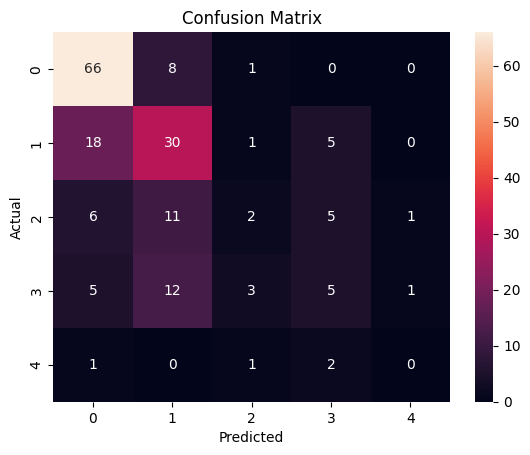

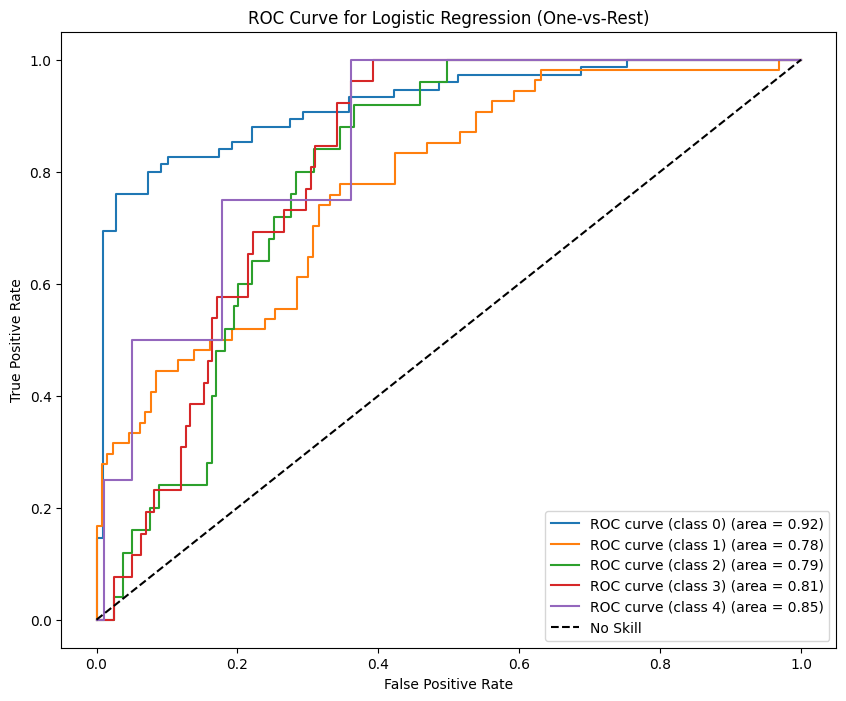

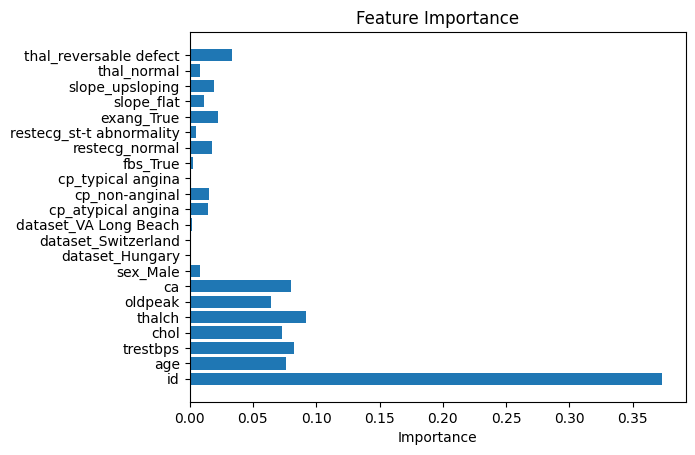

Sample Prediction (0 = No Disease, 1 = Disease): [0]


In [7]:
#Major Project
# Heart Disease Prediction

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.impute import SimpleImputer # Import SimpleImputer


# load dataset
df = pd.read_csv("heart.csv")

print(df.head())
print(df.info())


# check missing values
print(df.isnull().sum())


# split features and target
X = df.drop("num", axis=1)
y = df["num"]

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Store column names before X becomes a NumPy array
X_columns = X.columns

# Impute missing values after one-hot encoding
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# train models
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)


# predictions
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)


# evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


# confusion matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# roc curve for multiclass (One-vs-Rest)
lr_probs = lr_model.predict_proba(X_test)
n_classes = lr_probs.shape[1]

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    y_test_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_binary, lr_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (class {i}) (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()


# feature importance
importances = dt_model.feature_importances_
features = X_columns  # Use stored column names

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()


# sample prediction
sample = X_test[0].reshape(1, -1)
prediction = lr_model.predict(sample)

print("Sample Prediction (0 = No Disease, 1 = Disease):", prediction)
